# Week 6: Neural Network American Put Pricer
## Imitating the Binomial Baseline with a PyTorch MLP

**Author:** Sarthak Somani  
**Objective:** Generate synthetic American put contracts, label them with the Week 4 CRR binomial pricer, train an MLP to imitate that mapping, and check whether the network is financially sensible (not just low average error).

This notebook is the narrative/report layer. All real logic lives in `data.py`, `split.py`, `model.py`, `train.py`, `evaluate.py`, and `surface.py` in this folder, each covered by `test_neural_pricer.py`. Running this notebook end to end reproduces every metric and plot in the report.

### Requirements
```
numpy
matplotlib
torch
```

In [1]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

from data import FEATURE_ORDER, RANGES, check_labels, generate_labels, load_dataset, sample_contracts, save_dataset
from split import standardize, train_val_test_split
from model import PutPricerNet
from train import plot_learning_curve, train_model
from evaluate import compute_metrics, moneyness_bucket_mae, plot_pred_vs_true
from surface import build_surface, plot_surfaces, run_sanity_checks

SEED = 42
LABEL_STEPS = 500
N_CONTRACTS = 12_000

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"NumPy version: {np.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

NumPy version: 2.2.6
PyTorch version: 2.9.0+cpu
Device: cpu


---
# Part A: Dataset Generation

## A.1: Sample Synthetic Contracts

Ranges (documented, financially meaningful):

| Feature | Range |
|---|---|
| S0 | 60 to 140 |
| K | 80 to 120 |
| T (years) | 0.05 to 2.0 |
| r | 0.00 to 0.10 |
| sigma | 0.10 to 0.50 |

A fixed binomial step count (500) is used for every label so the network never has to learn discretization noise mixed in with true pricing shape.

In [2]:
X = sample_contracts(N_CONTRACTS, seed=SEED)

print(f"Sampled {len(X)} contracts")
for i, feature in enumerate(FEATURE_ORDER):
    lo, hi = RANGES[feature]
    print(f"{feature:6s}: range=[{lo}, {hi}], sampled=[{X[:, i].min():.4f}, {X[:, i].max():.4f}]")
print(X[:3])

Sampled 12000 contracts
S0    : range=[60.0, 140.0], sampled=[60.0011, 139.9982]
K     : range=[80.0, 120.0], sampled=[80.0008, 119.9993]
T     : range=[0.05, 2.0], sampled=[0.0501, 1.9999]
r     : range=[0.0, 0.1], sampled=[0.0000, 0.1000]
sigma : range=[0.1, 0.5], sampled=[0.1000, 0.5000]
[[1.21916484e+02 1.00722628e+02 1.55711514e+00 8.02327344e-02
  4.15391353e-01]
 [9.51102752e+01 9.41453569e+01 1.10021121e+00 1.70784058e-02
  3.30224834e-01]
 [1.28687834e+02 8.30022332e+01 4.15854293e-01 4.61549883e-02
  2.46328567e-01]]


## A.2: Generate Binomial Labels

Labels come from the Week 4 pricer, `crr_put_price(..., american=True)`, imported directly from `binomial-tree/american_put.py` (no reimplementation). This is the most important quality-control step in the whole pipeline: any bug in the Week 4 pricer would be faithfully learned by the network.

In [3]:
y = generate_labels(X, steps=LABEL_STEPS)
check_labels(X, y)

label range: [0.000000, 59.804871], mean=14.812231
intrinsic violations: 0


## A.3: Save the Dataset

Saved so training can be rerun without regenerating 12,000 binomial labels.

In [4]:
save_dataset("artifacts/week6_option_data.npz", X, y, LABEL_STEPS, SEED)
X, y, loaded_steps, loaded_seed = load_dataset("artifacts/week6_option_data.npz")
print(f"Reloaded {len(X)} contracts, steps={loaded_steps}, seed={loaded_seed}")

Reloaded 12000 contracts, steps=500, seed=42


---
# Part B: Training

## B.1: Split and Standardize

80/10/10 train/val/test split. Scaling statistics (`x_mean`, `x_std`) are computed on the training set only and reused for validation, test, and later inference — this is the single most important leakage rule in the whole pipeline.

In [5]:
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y, seed=SEED)
X_train_s, X_val_s, X_test_s, x_mean, x_std = standardize(X_train, X_val, X_test)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")
print(f"x_mean: {x_mean}")
print(f"x_std:  {x_std}")

Train: 9600, Val: 1200, Test: 1200
x_mean: [9.96304385e+01 1.00087793e+02 1.02450532e+00 5.03479437e-02
 2.99971153e-01]
x_std:  [23.10137168 11.58485738  0.5626406   0.02884127  0.11543046]


## B.2: Tensors and Model

A compact MLP: 5 raw inputs (`S0, K, T, r, sigma`) → two hidden layers of 128 ReLU units → one predicted price. No sigmoid on the output — prices are not probabilities.

In [6]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_t = torch.tensor(X_val_s, dtype=torch.float32)
y_val_t = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
X_test_t = torch.tensor(X_test_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=256, shuffle=True)

model = PutPricerNet(input_dim=5, hidden=128)
print(model)

PutPricerNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


## B.3: Train with Best-Checkpoint Selection

Adam optimizer, MSE loss, 300 epochs. We keep the model weights from whichever epoch had the lowest validation loss, not the final epoch — guards against reporting an overfit snapshot.

000 train=326.327768 val=194.695755


025 train=0.176413 val=0.180139


050 train=0.064477 val=0.072395


075 train=0.038005 val=0.045345


100 train=0.025797 val=0.031877


...

175 train=0.011967 val=0.016182


200 train=0.009679 val=0.016376


225 train=0.008112 val=0.013730


250 train=0.007057 val=0.010686


275 train=0.005866 val=0.009445


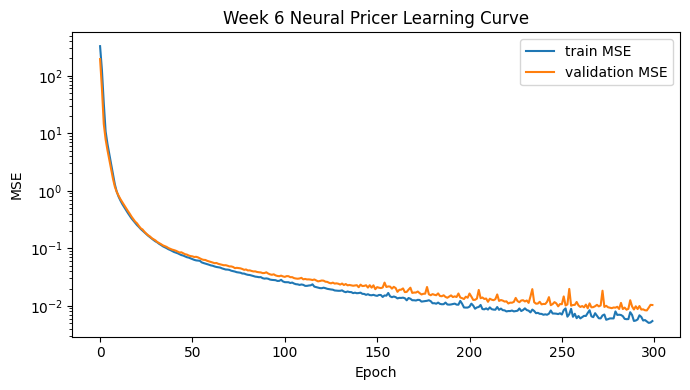

In [7]:
history, best_state = train_model(model, train_loader, X_val_t, y_val_t, epochs=300, lr=1e-3)
plot_learning_curve(history, "figures/learning_curve.png")

---
# Part C: Evaluation and Finance Checks

## C.1: Test Metrics and Error by Moneyness

A single average error hides where the pricer fails. We report MAE/RMSE/max-abs-error plus MAE bucketed by moneyness (`S0/K`): deep ITM (< 0.85), near ATM (0.85–1.15), and deep OTM (> 1.15).

MAE:     0.0634
RMSE:    0.0853
Max abs: 0.5608

deep ITM put: n= 364, MAE=0.0611
near ATM    : n= 443, MAE=0.0769
deep OTM put: n= 393, MAE=0.0504


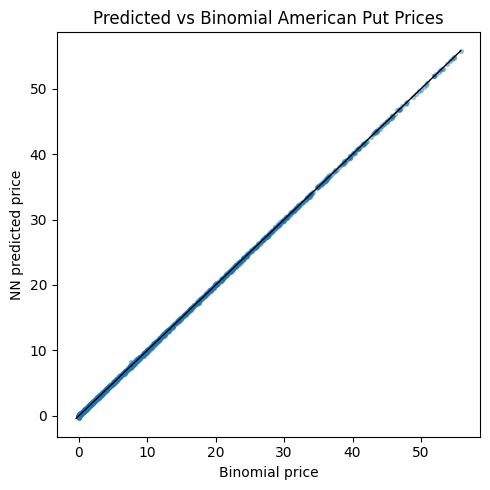

In [8]:
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t).numpy().reshape(-1)

err = pred_test - y_test
metrics = compute_metrics(pred_test, y_test)
print(f"MAE:     {metrics['mae']:.4f}")
print(f"RMSE:    {metrics['rmse']:.4f}")
print(f"Max abs: {metrics['max_abs']:.4f}")

print()
bucket_results = moneyness_bucket_mae(X_test, err)

plot_pred_vs_true(y_test, pred_test, "figures/pred_vs_binomial.png")

## C.2: Surface Comparison

The neural surface plotted beside the binomial surface, for a fixed `K=100, r=5%, sigma=25%` over `S0 × T`. Largest errors are expected near short maturities and the exercise boundary.

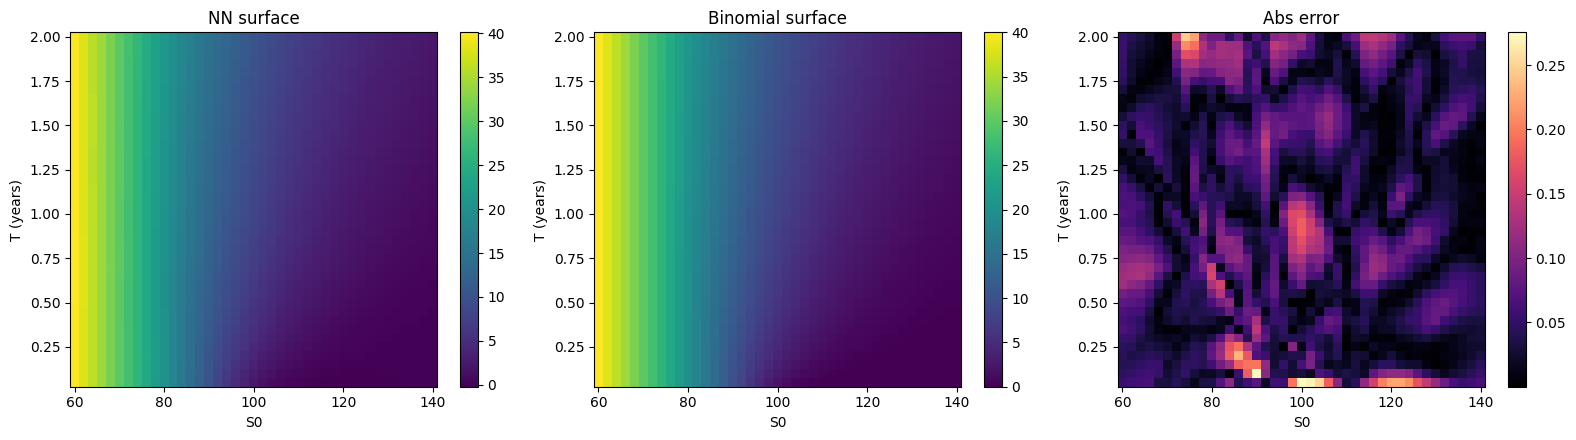

Max surface abs error: 0.2755
Mean surface abs error: 0.0485


In [9]:
nn_surface, binomial_surface, abs_error_surface = build_surface(model, x_mean, x_std, steps=LABEL_STEPS)
plot_surfaces(nn_surface, binomial_surface, abs_error_surface, "figures/surface_comparison.png")
print(f"Max surface abs error: {abs_error_surface.max():.4f}")
print(f"Mean surface abs error: {abs_error_surface.mean():.4f}")

## C.3: Finance Sanity Checks

On a fixed slice (`K=100, T=1, r=5%, sigma=25%`, sweeping `S0` from 60 to 140): the put price should be non-negative, should sit at or above intrinsic value `max(K - S0, 0)`, and should not increase as `S0` rises.

In [10]:
sanity_results = run_sanity_checks(model, x_mean, x_std)

monotonic violations: 0
negative predictions: 0
below intrinsic: 10


## C.4: Save the Model and Pipeline State

The saved artifact bundles weights, scaling statistics, feature order, label step count, and sampling ranges — everything needed so a future prediction can't silently use a different input convention.

In [11]:
artifact = {
    "model_state": best_state,
    "x_mean": x_mean,
    "x_std": x_std,
    "feature_order": FEATURE_ORDER,
    "label_steps": LABEL_STEPS,
    "ranges": RANGES,
}
torch.save(artifact, "artifacts/week6_neural_pricer.pt")
print("Saved artifact to artifacts/week6_neural_pricer.pt")

Saved artifact to artifacts/week6_neural_pricer.pt


---
# Summary and Reflection

In [12]:
print("=== Week 6 Summary ===")
print(f"Dataset: {N_CONTRACTS} contracts, labeled with crr_put_price(steps={LABEL_STEPS})")
print(f"Split: {len(X_train)}/{len(X_val)}/{len(X_test)} (train/val/test)")
print(f"Test MAE={metrics['mae']:.4f}, RMSE={metrics['rmse']:.4f}, Max abs={metrics['max_abs']:.4f}")
for name, res in bucket_results.items():
    print(f"  {name:12s}: n={res['n']:4d}, MAE={res['mae']:.4f}")
print(f"Sanity checks: {sanity_results}")
print()
print("Reflection: fill in after inspecting the moneyness-bucket MAE and surface error")
print("heatmap above — identify which region (deep ITM/OTM, short maturity, near the")
print("exercise boundary) has the largest error and why the MLP struggles there.")

=== Week 6 Summary ===
Dataset: 12000 contracts, labeled with crr_put_price(steps=500)
Split: 9600/1200/1200 (train/val/test)
Test MAE=0.0634, RMSE=0.0853, Max abs=0.5608
  deep ITM put: n= 364, MAE=0.0611
  near ATM    : n= 443, MAE=0.0769
  deep OTM put: n= 393, MAE=0.0504
Sanity checks: {'monotonic_violations': 0, 'negative_predictions': 0, 'intrinsic_violations': 10}

Reflection: fill in after inspecting the moneyness-bucket MAE and surface error
heatmap above — identify which region (deep ITM/OTM, short maturity, near the
exercise boundary) has the largest error and why the MLP struggles there.
